In [ ]:
import pandas as pd


In [ ]:
df= pd.read_csv("/content/FinalBlinkitDataset.csv")

In [ ]:
df.head()

,order_id,order_date,payment_method,order_total,customer_id,customer_name,area,customer_segment,product_id,product_name,...,brand,quantity,unit_price,item_total,delivery_time_minutes,distance_km,delivery_status,delivery_flag,order_month,order_type
0,1961864118,2024-07-17 08:34:01,Cash,3197.07,30065862,Urishilla Hegde,Allahabad,Regular,642612,Pet Treats,...,Pillay-Ahuja,3,517.03,1551.09,-5,0.96,On Time,On Time,2024-07,High Value
1,1549769649,2024-05-28 13:14:29,Cash,976.55,9573071,Ranveer Mahal,Thrissur,New,378676,Orange Juice,...,Baral-Kamdar,1,881.42,881.42,2,0.98,On Time,On Time,2024-05,Normal
2,9185164487,2024-09-23 13:07:12,UPI,839.05,45477575,Aarna Bawa,Vellore,Inactive,741341,Eggs,...,Prasad LLC,2,923.84,1847.68,4,3.83,On Time,On Time,2024-09,Normal
3,9644738826,2023-11-24 16:16:56,Card,440.23,88067569,Aayush Sengupta,Gaya,Premium,561860,Orange Juice,...,Gupta Ltd,1,874.78,874.78,-1,2.76,On Time,On Time,2023-11,Normal
4,5427684290,2023-11-20 05:00:39,Cash,2526.68,83298567,Vansha Kuruvilla,Asansol,Premium,602241,Nuts,...,Bahl-Pau,2,976.55,1953.10,1,2.63,On Time,On Time,2023-11,High Value


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
payment_method,0
order_total,0
customer_id,0
customer_name,0
area,0
customer_segment,0
product_id,0
product_name,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               5000 non-null   int64  
 1   order_date             5000 non-null   object 
 2   payment_method         5000 non-null   object 
 3   order_total            5000 non-null   float64
 4   customer_id            5000 non-null   int64  
 5   customer_name          5000 non-null   object 
 6   area                   5000 non-null   object 
 7   customer_segment       5000 non-null   object 
 8   product_id             5000 non-null   int64  
 9   product_name           5000 non-null   object 
 10  category               5000 non-null   object 
 11  brand                  5000 non-null   object 
 12  quantity               5000 non-null   int64  
 13  unit_price             5000 non-null   float64
 14  item_total             5000 non-null   float64
 15  deli

In [ ]:
df.describe()

,order_id,order_total,customer_id,product_id,quantity,unit_price,item_total,delivery_time_minutes,distance_km
count,5.000000e+03,5000.00000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.029129e+09,2201.86170,5.009685e+07,509974.939600,2.006800,493.157900,994.483086,4.443000,2.718048
std,2.863533e+09,1303.02438,2.919082e+07,293678.307475,0.820542,298.075647,774.158426,8.063929,1.290306
min,6.046500e+04,13.25000,3.181300e+04,4452.000000,1.000000,12.320000,12.320000,-5.000000,0.500000
25%,2.531421e+09,1086.21500,2.404314e+07,257719.000000,1.000000,227.220000,374.680000,-1.000000,1.590000
50%,5.074378e+09,2100.69000,4.997808e+07,540618.000000,2.000000,448.160000,795.360000,2.000000,2.690000
75%,7.488579e+09,3156.88250,7.621215e+07,747801.000000,3.000000,781.080000,1492.060000,8.000000,3.850000
max,9.998298e+09,6721.46000,9.989390e+07,993331.000000,3.000000,995.980000,2987.940000,30.000000,5.000000


In [ ]:
#Data cleaning(Final touch)
df.drop_duplicates(inplace= True)


In [ ]:
# Total sales

df['order_total'].sum()

np.float64(11009308.5)

In [ ]:
import datetime as dt

In [ ]:
# Monthly sales
df.groupby(df['order_date'].dt.to_period('M'))['order_total'].sum()

,order_total
order_date,
2023-03,272878.96
2023-04,554344.77
2023-05,608213.54
2023-06,505227.66
2023-07,567639.91
2023-08,623472.35
2023-09,571117.81
2023-10,578369.83
2023-11,567783.74


In [ ]:
df.groupby('category')['order_total'].sum()

,order_total
category,
Baby Care,741055.06
Cold Drinks & Juices,828002.23
Dairy & Breakfast,1244368.69
Fruits & Vegetables,1085102.76
Grocery & Staples,1005494.87
Household Care,1136440.47
Instant & Frozen Food,741183.31
Personal Care,1003163.40
Pet Care,1125103.80


In [ ]:
import matplotlib.pyplot as plt
import seaborn as srn


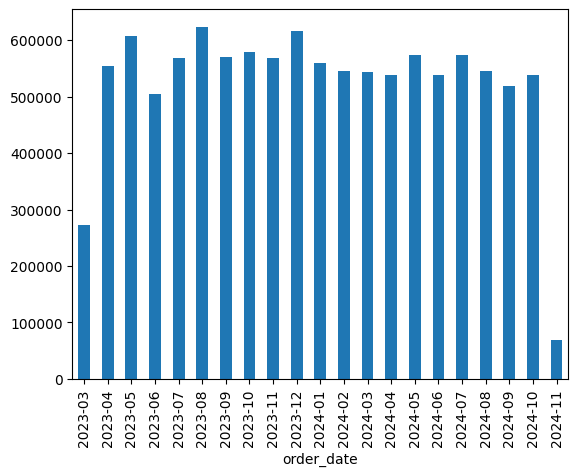

In [ ]:
#Visualizing
monthly_sales= df.groupby(df['order_date'].dt.to_period('M'))['order_total'].sum()
monthly_sales.plot(kind='bar')
plt.show()

In [ ]:
# Rfm analysis
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm=df.groupby('customer_id').agg({
    'order_date':lambda x: (snapshot_date - x.max()).days,
    'order_id' : 'count',
    'order_total':'sum'
})

rfm.columns = ['recency','Frequency','Monetary']

In [ ]:
# Customer Segmentation

rfm['R_score'] = pd.qcut(rfm['recency'],4,labels = [4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),4,labels = [1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'],4,labels = [1,2,3,4])

rfm['Rfm_score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

In [ ]:
#churn prediction

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

#Example target (create dummy)

df['churn'] = df['delivery_flag'].apply(lambda x : 1 if x=='Late' else 0)

# Define features (X) and target (y)
x = df[['order_total','quantity']] # Assuming 'f' was a typo for 'df'
y = df['churn']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42) # Corrected test_size and added random_state for reproducibility

model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
model.fit(x_train,y_train)

model.score(x_test,y_test)

1.0

In [ ]:
df.to_csv("final_dataset_processed.csv",index=False)

In [ ]:
from google.colab import files
files.download("final_dataset_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>